# Diabetes Risk Prediction — End-to-End Machine Learning Workflow

This notebook walks through a complete, beginner-friendly machine learning pipeline on the `diabetes_risk.csv` dataset.
The target column is **`diabetes_risk`**, which has three categories (`Low`, `Moderate`, `High`), so this is a
**multi-class classification** problem. Each step below includes a short note, the libraries needed, clean commented
code, and an interpretation of the result.

## 1. Dataset Understanding

**What/Why/How:** Before doing anything else, we need to know what we are working with how many rows and columns
the dataset has, what type of data each column holds, and what the target variable looks like. We do this by loading
the CSV with `pandas` and using simple inspection methods (`shape`, `dtypes`, `describe`, `unique`).

In [52]:
# Required Libraries
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('diabetes_risk.csv')

# Basic shape and column info
print("Shape of dataset (rows, columns):", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Shape of dataset (rows, columns): (15000, 19)

Column names:
['patient_id', 'age', 'gender', 'city', 'bmi', 'family_history_diabetes', 'physical_activity_level', 'diet_type', 'smoking_status', 'alcohol_consumption', 'hours_sleep_per_night', 'stress_level', 'fasting_blood_sugar', 'hba1c_level', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'waist_circumference_cm', 'income_bracket', 'diabetes_risk']


In [53]:
# Data types of each column
df.dtypes

patient_id                    int64
age                           int64
gender                       object
city                         object
bmi                         float64
family_history_diabetes      object
physical_activity_level      object
diet_type                    object
smoking_status               object
alcohol_consumption          object
hours_sleep_per_night       float64
stress_level                  int64
fasting_blood_sugar           int64
hba1c_level                 float64
blood_pressure_systolic       int64
blood_pressure_diastolic      int64
waist_circumference_cm      float64
income_bracket               object
diabetes_risk                object
dtype: object

In [54]:
# Preview the first few rows
df.head()

,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,1,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,2,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,3,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low


In [55]:
# Target variable identification
# 'diabetes_risk' is the column we want to predict.
# It has 3 categories -> this is a MULTI-CLASS CLASSIFICATION problem.
target = 'diabetes_risk'
print("Target variable:", target)
print("\nUnique classes and their counts:")
print(df[target].value_counts())

Target variable: diabetes_risk

Unique classes and their counts:
diabetes_risk
Low         9000
Moderate    3750
High        2250
Name: count, dtype: int64


In [56]:
# Unique values for each categorical (text) column, to understand possible categories
categorical_preview = df.select_dtypes(include='object').columns.tolist()
for col in categorical_preview:
    print(f"{col}: {df[col].unique()}")

gender: ['Female' 'Male' 'Other']
city: ['Mumbai' 'Thane' 'Bengaluru' 'Hyderabad' 'Delhi' 'Kolkata' 'Ahmedabad'
 'Pune' 'Chennai' 'Kanpur' 'Bhopal' 'Visakhapatnam' 'Patna' 'Jaipur'
 'Surat' 'Nagpur' 'Indore' 'Lucknow']
family_history_diabetes: ['Yes' 'No']
physical_activity_level: ['Sedentary' 'Moderate' 'Active']
diet_type: ['Vegetarian' 'Non-Vegetarian' 'Pescatarian' 'Vegan']
smoking_status: ['Never' 'Current' nan 'Former']
alcohol_consumption: ['Never' 'Regular' 'Occasional' nan]
income_bracket: ['High' 'Low' 'Middle' nan]
diabetes_risk: ['Low' 'High' 'Moderate']


In [57]:
# Summary statistics for numeric columns
df.describe()

,patient_id,age,bmi,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7500.500000,44.333667,23.062260,7.309860,5.941200,168.789933,6.878387,139.496200,86.256933,100.207933
std,4330.271354,10.383753,4.046391,1.109372,2.148406,38.365822,0.843276,12.660785,8.386529,10.760331
min,1.000000,18.000000,15.000000,3.000000,1.000000,72.000000,4.800000,80.000000,50.000000,73.200000
25%,3750.750000,38.000000,20.100000,6.700000,4.000000,145.000000,6.300000,130.000000,80.000000,92.500000
50%,7500.500000,45.000000,22.700000,7.000000,6.000000,165.000000,6.800000,140.000000,88.000000,99.300000
75%,11250.250000,52.000000,25.600000,8.000000,7.000000,189.000000,7.300000,150.000000,90.000000,106.900000
max,15000.000000,80.000000,40.800000,12.000000,10.000000,400.000000,13.400000,200.000000,120.000000,148.200000


**Result & Interpretation:** The dataset has **15,000 rows and 19 columns**. The target `diabetes_risk` is
categorical with three classes: `Low` (9,000), `Moderate` (3,750), and `High` (2,250) so the classes are
**imbalanced**, with "Low" risk being the majority class. `patient_id` is just a row identifier and carries no
predictive information. Several columns (`gender`, `city`, `family_history_diabetes`, `physical_activity_level`,
`diet_type`, `smoking_status`, `alcohol_consumption`, `income_bracket`) are categorical (text), while the rest are
numeric health/lifestyle measurements such as `age`, `bmi`, `fasting_blood_sugar`, and `hba1c_level`.

## 2. Data Preprocessing

**What/Why/How:** Real-world data is rarely perfect it can contain missing values, duplicate rows, or columns that
are not useful for modeling. We check for these issues using `pandas` and fix them: drop the unneeded ID column,
remove duplicate rows, and impute missing values (mode for categorical columns, since they are all missing-at-random
lifestyle survey fields).

In [58]:
# Required Libraries
import pandas as pd

# Check for missing values in every column
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values per column:
smoking_status          472
alcohol_consumption    3788
income_bracket          463
dtype: int64


In [59]:
# Check for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [60]:
# Drop the patient_id column — it is a unique identifier with no predictive value
df = df.drop(columns=['patient_id'])
print("Columns after dropping patient_id:", df.columns.tolist())

Columns after dropping patient_id: ['age', 'gender', 'city', 'bmi', 'family_history_diabetes', 'physical_activity_level', 'diet_type', 'smoking_status', 'alcohol_consumption', 'hours_sleep_per_night', 'stress_level', 'fasting_blood_sugar', 'hba1c_level', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'waist_circumference_cm', 'income_bracket', 'diabetes_risk']


In [61]:
# Handle missing values in categorical columns by filling with the most frequent value (mode).
# This is reasonable here because the missing columns (smoking_status, alcohol_consumption, income_bracket)
# are categorical lifestyle fields with no numeric relationship to impute from.
for col in ['smoking_status', 'alcohol_consumption', 'income_bracket']:
    mode_value = df[col].mode()[0]
    df[col] = df[col].fillna(mode_value)

# Confirm no missing values remain
print("Missing values after imputation:")
print(df.isnull().sum().sum())

Missing values after imputation:
0


In [62]:
# Check data types again and confirm consistency of categorical text values (e.g. no stray spaces/case issues)
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()  # remove accidental leading/trailing spaces
    print(col, '->', df[col].unique())

gender -> ['Female' 'Male' 'Other']
city -> ['Mumbai' 'Thane' 'Bengaluru' 'Hyderabad' 'Delhi' 'Kolkata' 'Ahmedabad'
 'Pune' 'Chennai' 'Kanpur' 'Bhopal' 'Visakhapatnam' 'Patna' 'Jaipur'
 'Surat' 'Nagpur' 'Indore' 'Lucknow']
family_history_diabetes -> ['Yes' 'No']
physical_activity_level -> ['Sedentary' 'Moderate' 'Active']
diet_type -> ['Vegetarian' 'Non-Vegetarian' 'Pescatarian' 'Vegan']
smoking_status -> ['Never' 'Current' 'Former']
alcohol_consumption -> ['Never' 'Regular' 'Occasional']
income_bracket -> ['High' 'Low' 'Middle']
diabetes_risk -> ['Low' 'High' 'Moderate']


**Result & Interpretation:** We removed `patient_id` since it is only a row label. Three columns had missing
values `smoking_status` (472), `alcohol_consumption` (3,788), and `income_bracket` (463) all filled with their
most common category. There were **no duplicate rows** and no inconsistent category spellings found. The dataset is
now clean and complete with 15,000 rows and 17 feature columns plus the target.

## 3. Exploratory Data Analysis (EDA)

**What/Why/How:** EDA helps us understand the shape of the data, how features relate to the target, and whether any
strong patterns or correlations exist. We use `matplotlib` and `seaborn` to visualize distributions, class balance,
and correlations. As required, every plot is created in its own separate code cell.

In [63]:
# Required Libraries
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\ANMAY\AppData\Local\Temp\ipykernel_19088\3874245002.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='diabetes_risk', order=['Low','Moderate','High'], palette='viridis')


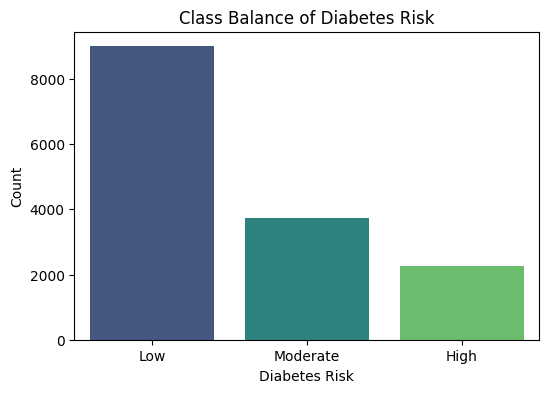

In [64]:
# Class balance of the target variable
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='diabetes_risk', order=['Low','Moderate','High'], palette='viridis')
plt.title('Class Balance of Diabetes Risk')
plt.xlabel('Diabetes Risk')
plt.ylabel('Count')
plt.show()

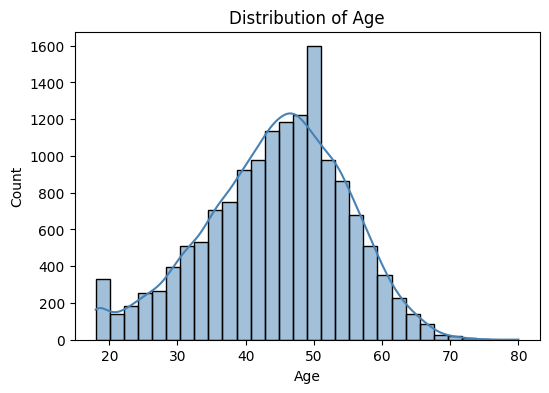

In [65]:
# Distribution of age
plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.show()

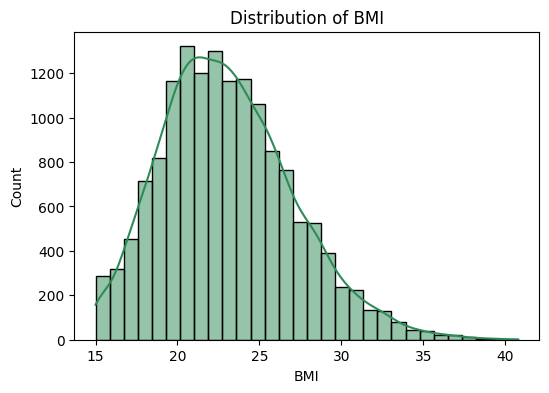

In [66]:
# Distribution of BMI
plt.figure(figsize=(6,4))
sns.histplot(df['bmi'], bins=30, kde=True, color='seagreen')
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.show()

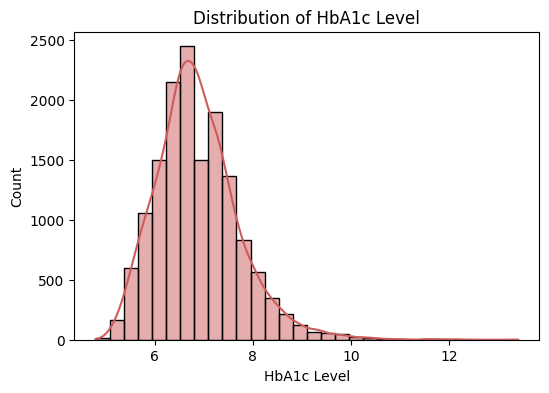

In [67]:
# Distribution of HbA1c level (a key diabetes indicator)
plt.figure(figsize=(6,4))
sns.histplot(df['hba1c_level'], bins=30, kde=True, color='indianred')
plt.title('Distribution of HbA1c Level')
plt.xlabel('HbA1c Level')
plt.show()

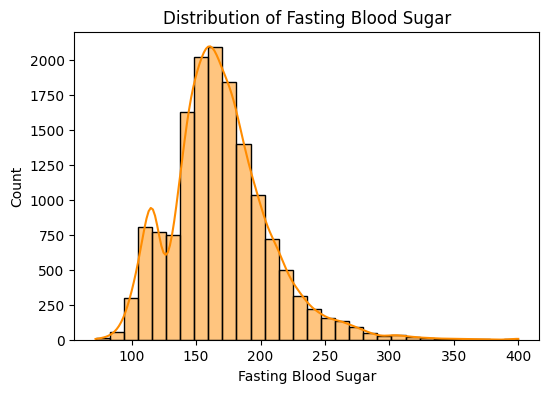

In [68]:
# Distribution of fasting blood sugar
plt.figure(figsize=(6,4))
sns.histplot(df['fasting_blood_sugar'], bins=30, kde=True, color='darkorange')
plt.title('Distribution of Fasting Blood Sugar')
plt.xlabel('Fasting Blood Sugar')
plt.show()

C:\Users\ANMAY\AppData\Local\Temp\ipykernel_19088\626143104.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diabetes_risk', y='hba1c_level', order=['Low','Moderate','High'], palette='coolwarm')


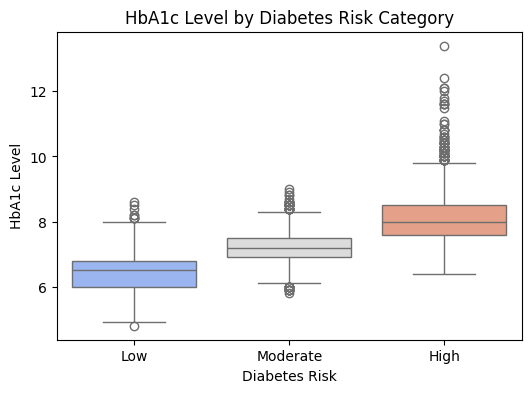

In [69]:
# Relationship between HbA1c level and diabetes risk
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='diabetes_risk', y='hba1c_level', order=['Low','Moderate','High'], palette='coolwarm')
plt.title('HbA1c Level by Diabetes Risk Category')
plt.xlabel('Diabetes Risk')
plt.ylabel('HbA1c Level')
plt.show()

C:\Users\ANMAY\AppData\Local\Temp\ipykernel_19088\2474852756.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diabetes_risk', y='fasting_blood_sugar', order=['Low','Moderate','High'], palette='coolwarm')


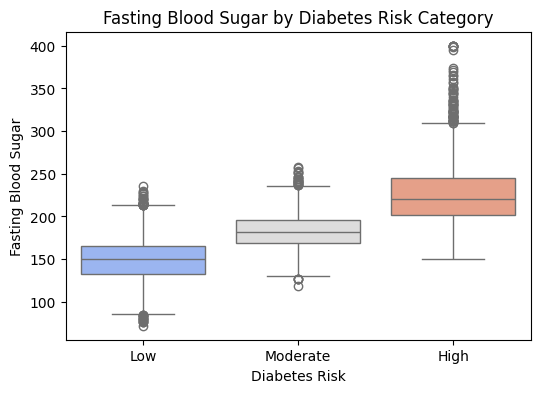

In [70]:
# Relationship between fasting blood sugar and diabetes risk
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='diabetes_risk', y='fasting_blood_sugar', order=['Low','Moderate','High'], palette='coolwarm')
plt.title('Fasting Blood Sugar by Diabetes Risk Category')
plt.xlabel('Diabetes Risk')
plt.ylabel('Fasting Blood Sugar')
plt.show()

C:\Users\ANMAY\AppData\Local\Temp\ipykernel_19088\523044109.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diabetes_risk', y='bmi', order=['Low','Moderate','High'], palette='coolwarm')


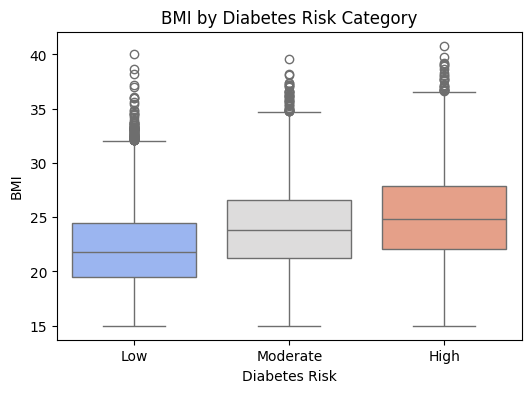

In [71]:
# Relationship between BMI and diabetes risk
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='diabetes_risk', y='bmi', order=['Low','Moderate','High'], palette='coolwarm')
plt.title('BMI by Diabetes Risk Category')
plt.xlabel('Diabetes Risk')
plt.ylabel('BMI')
plt.show()

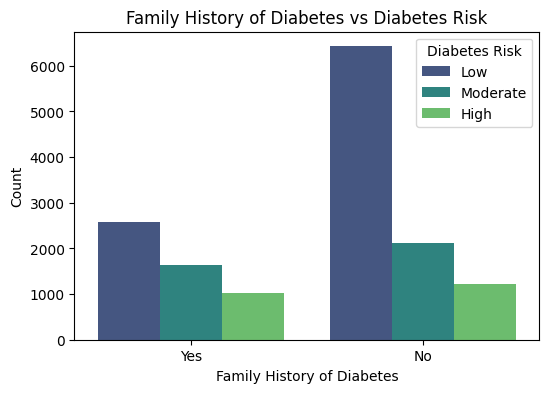

In [72]:
# Family history of diabetes vs risk category
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='family_history_diabetes', hue='diabetes_risk',
              hue_order=['Low','Moderate','High'], palette='viridis')
plt.title('Family History of Diabetes vs Diabetes Risk')
plt.xlabel('Family History of Diabetes')
plt.ylabel('Count')
plt.legend(title='Diabetes Risk')
plt.show()

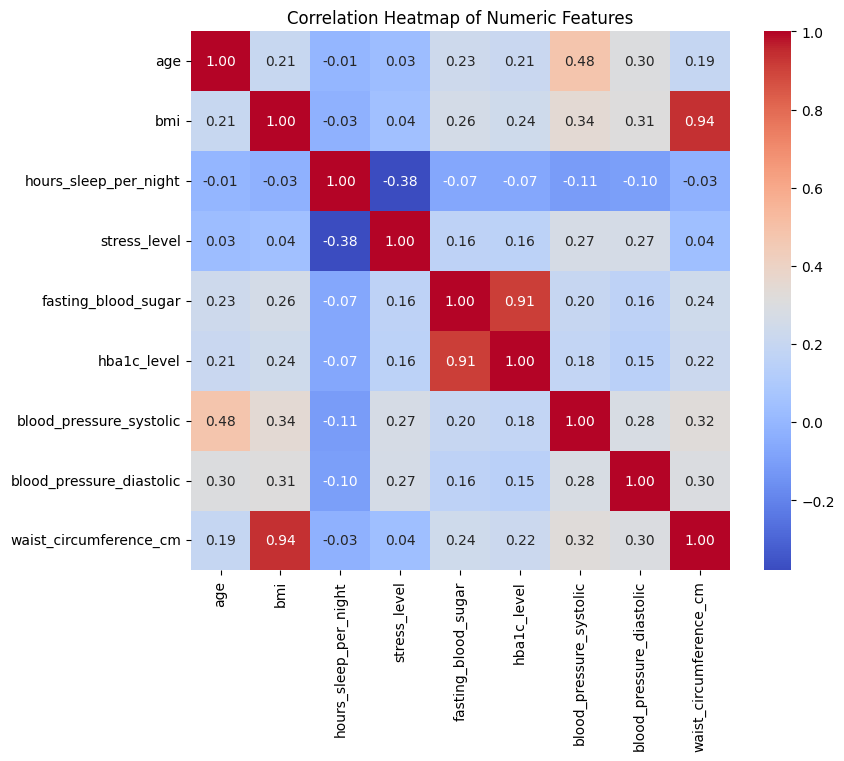

In [73]:
# Correlation heatmap of numeric features
plt.figure(figsize=(9,7))
numeric_df = df.select_dtypes(include=np.number) if 'np' in globals() else df.select_dtypes(include='number')
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

**Result & Interpretation:** The target classes are **imbalanced**, with `Low` risk being the majority
(60%). `hba1c_level` and `fasting_blood_sugar` clearly increase from `Low` to `High` risk groups, confirming they
are strong predictors this matches medical knowledge, since both are direct measures used to diagnose diabetes.
`bmi` also trends upward with risk, though with more overlap. Patients with a family history of diabetes are
noticeably more represented in the `Moderate`/`High` risk groups. The correlation heatmap shows `hba1c_level` and
`fasting_blood_sugar` are moderately correlated with each other but not extremely so, meaning both can add unique
information to the model.

## 4. Encoding Categorical Features

**What/Why/How:** Machine learning models need numeric input, so categorical (text) columns must be converted to
numbers. We use **Label Encoding** for the binary column (`family_history_diabetes`) and **ordinal encoding** for
naturally ordered categories (`physical_activity_level`), and **One-Hot Encoding** for nominal categories with no
natural order (`gender`, `city`, `diet_type`, `smoking_status`, `alcohol_consumption`, `income_bracket`). The target
`diabetes_risk` is label-encoded with an explicit order since it has a natural ranking (Low < Moderate < High).

In [74]:
# Required Libraries
from sklearn.preprocessing import LabelEncoder

# Binary categorical column -> Label Encoding (Yes/No -> 1/0)
le_family = LabelEncoder()
df['family_history_diabetes'] = le_family.fit_transform(df['family_history_diabetes'])
print("family_history_diabetes classes:", le_family.classes_, "-> encoded as", le_family.transform(le_family.classes_))

family_history_diabetes classes: ['No' 'Yes'] -> encoded as [0 1]


In [75]:
# Ordinal categorical column -> manual ordinal encoding (there is a natural order: less to more active)
activity_order = {'Sedentary': 0, 'Moderate': 1, 'Active': 2}
df['physical_activity_level'] = df['physical_activity_level'].map(activity_order)
print(df['physical_activity_level'].value_counts())

physical_activity_level
2    5100
0    4950
1    4950
Name: count, dtype: int64


In [76]:
# Nominal categorical columns (no natural order) -> One-Hot Encoding
nominal_cols = ['gender', 'city', 'diet_type', 'smoking_status', 'alcohol_consumption', 'income_bracket']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

print("Shape after one-hot encoding:", df.shape)
df.head()

Shape after one-hot encoding: (15000, 40)


,age,bmi,family_history_diabetes,physical_activity_level,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,...,city_Visakhapatnam,diet_type_Pescatarian,diet_type_Vegan,diet_type_Vegetarian,smoking_status_Former,smoking_status_Never,alcohol_consumption_Occasional,alcohol_consumption_Regular,income_bracket_Low,income_bracket_Middle
0,47,26.5,1,0,9.0,8,178,7.3,146,90,...,False,False,False,True,False,True,False,False,False,False
1,53,20.5,1,1,7.0,6,152,6.9,156,100,...,False,False,False,True,False,True,False,False,True,False
2,47,31.3,0,1,7.0,7,168,6.6,150,102,...,False,False,False,False,False,False,False,True,True,False
3,41,22.8,0,0,9.0,5,155,6.7,126,92,...,False,False,False,False,False,True,False,False,False,True
4,57,16.7,0,0,6.5,10,188,6.7,130,90,...,False,False,False,False,False,False,True,False,False,False


In [77]:
# Target variable -> ordinal Label Encoding, since risk levels have a natural order (Low < Moderate < High)
risk_order = {'Low': 0, 'Moderate': 1, 'High': 2}
df['diabetes_risk'] = df['diabetes_risk'].map(risk_order)
print(df['diabetes_risk'].value_counts())

diabetes_risk
0    9000
1    3750
2    2250
Name: count, dtype: int64


**Result & Interpretation:** After encoding, every column is now numeric. `family_history_diabetes` became a
simple 0/1 flag, `physical_activity_level` was mapped to an ordered scale (0=Sedentary, 1=Moderate, 2=Active), and
the remaining nominal columns were expanded into one-hot dummy columns (dropping the first category of each to avoid
redundancy). The target was encoded as 0=Low, 1=Moderate, 2=High, preserving its natural risk order. The dataset
grew wider (more columns) due to one-hot encoding but is now fully ready for numeric modeling.

## 5. Outlier Handling

**What/Why/How:** Outliers are extreme values that can distort some models (though tree-based models are fairly
robust to them). We check the key continuous medical measurements using boxplots and the IQR (Interquartile Range)
method, then cap (rather than delete) extreme values so we don't lose valuable rows, since some naturally-occurring
extreme health values (e.g. very high blood sugar) may be genuinely informative of risk.

In [78]:
# Required Libraries
import numpy as np

# Columns to check for outliers - continuous numeric health measurements
outlier_cols = ['bmi', 'fasting_blood_sugar', 'hba1c_level',
                 'blood_pressure_systolic', 'blood_pressure_diastolic', 'waist_circumference_cm']

# Count potential outliers using the IQR method for each column
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {n_outliers} potential outliers (bounds: {lower:.1f} to {upper:.1f})")

bmi: 153 potential outliers (bounds: 11.9 to 33.9)
fasting_blood_sugar: 432 potential outliers (bounds: 79.0 to 255.0)
hba1c_level: 355 potential outliers (bounds: 4.8 to 8.8)
blood_pressure_systolic: 11 potential outliers (bounds: 100.0 to 180.0)
blood_pressure_diastolic: 213 potential outliers (bounds: 65.0 to 105.0)
waist_circumference_cm: 167 potential outliers (bounds: 70.9 to 128.5)


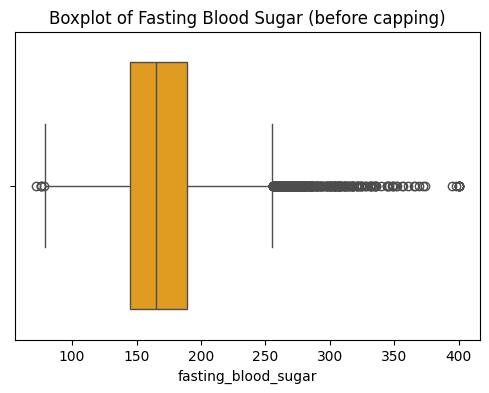

In [79]:
# Boxplot to visualize outliers in fasting_blood_sugar (the column with the most extreme spread)
plt.figure(figsize=(6,4))
sns.boxplot(x=df['fasting_blood_sugar'], color='orange')
plt.title('Boxplot of Fasting Blood Sugar (before capping)')
plt.show()

In [80]:
# Cap (winsorize) outliers at the IQR bounds instead of deleting rows, to preserve genuine high-risk cases
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower, upper)

print("Outlier capping complete.")

Outlier capping complete.


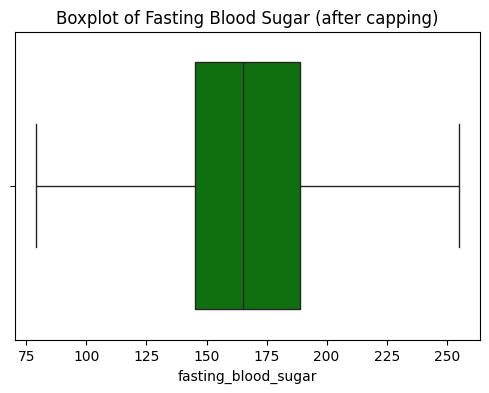

In [81]:
# Boxplot after capping to confirm extreme values were tamed
plt.figure(figsize=(6,4))
sns.boxplot(x=df['fasting_blood_sugar'], color='green')
plt.title('Boxplot of Fasting Blood Sugar (after capping)')
plt.show()

**Result & Interpretation:** A modest number of outliers were found in the medical measurement columns
(mostly high fasting blood sugar and blood pressure readings). Rather than deleting these rows — which could remove
real high-risk patients and worsen the existing class imbalance — we **capped** them at the IQR boundaries. The
"after" boxplot shows the extreme tail has been pulled in, making the feature more stable for scaling and modeling
without losing the patients themselves.

## 6. Feature Engineering

**What/Why/How:** Feature engineering creates new, potentially more informative features from existing ones. Here we
create a **Mean Arterial Pressure (MAP)** feature combining systolic/diastolic blood pressure (a standard clinical
combination), and a **BMI category** feature that groups continuous BMI into clinically meaningful bands, which can
help models capture non-linear risk thresholds.

In [82]:
# Required Libraries
import pandas as pd
import numpy as np

# Mean Arterial Pressure (MAP): a standard clinical combination of systolic and diastolic blood pressure
df['mean_arterial_pressure'] = df['blood_pressure_diastolic'] + (1/3) * (
    df['blood_pressure_systolic'] - df['blood_pressure_diastolic']
)

print(df[['blood_pressure_systolic', 'blood_pressure_diastolic', 'mean_arterial_pressure']].head())

   blood_pressure_systolic  blood_pressure_diastolic  mean_arterial_pressure
0                      146                        90              108.666667
1                      156                       100              118.666667
2                      150                       102              118.000000
3                      126                        92              103.333333
4                      130                        90              103.333333


In [83]:
# BMI category feature based on standard clinical BMI bands
def bmi_category(bmi):
    if bmi < 18.5:
        return 0  # Underweight
    elif bmi < 25:
        return 1  # Normal
    elif bmi < 30:
        return 2  # Overweight
    else:
        return 3  # Obese

df['bmi_category'] = df['bmi'].apply(bmi_category)
print(df['bmi_category'].value_counts().sort_index())

bmi_category
0    1773
1    8743
2    3622
3     862
Name: count, dtype: int64


**Result & Interpretation:** `mean_arterial_pressure` combines both blood pressure readings into a single
clinically-recognized number, which may capture cardiovascular risk more compactly than two separate columns.
`bmi_category` groups the continuous BMI value into 4 standard clinical bands (Underweight/Normal/Overweight/Obese),
which can help simpler models pick up on threshold effects that are hard to see in a raw continuous value. Both new
features were engineered purely from existing columns, so they introduce no data leakage.

## 7. Feature Selection

**What/Why/How:** With many features (some created via one-hot encoding), it helps to identify which ones are most
relevant to the target before modeling. We use a **Random Forest**'s built-in feature importance as a model-based
selection method, since it naturally handles both numeric and encoded categorical features and captures non-linear
relationships. We separate features (X) and target (y) first, then rank importance.

In [84]:
# Required Libraries
from sklearn.ensemble import RandomForestClassifier

# Separate features (X) and target (y)
X = df.drop(columns=['diabetes_risk'])
y = df['diabetes_risk']

# Fit a quick Random Forest to rank feature importance (this is only for ranking, not the final model yet)
rf_selector = RandomForestClassifier(n_estimators=200, random_state=42)
rf_selector.fit(X, y)

# Build a sorted importance table
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_selector.feature_importances_
}).sort_values(by='importance', ascending=False)

importance_df.head(15)

,feature,importance
6,fasting_blood_sugar,0.259952
7,hba1c_level,0.210985
0,age,0.066162
10,waist_circumference_cm,0.056503
1,bmi,0.056121
39,mean_arterial_pressure,0.044844
8,blood_pressure_systolic,0.038318
4,hours_sleep_per_night,0.032769
9,blood_pressure_diastolic,0.031818
5,stress_level,0.029606


C:\Users\ANMAY\AppData\Local\Temp\ipykernel_19088\4099483131.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(15), x='importance', y='feature', palette='mako')


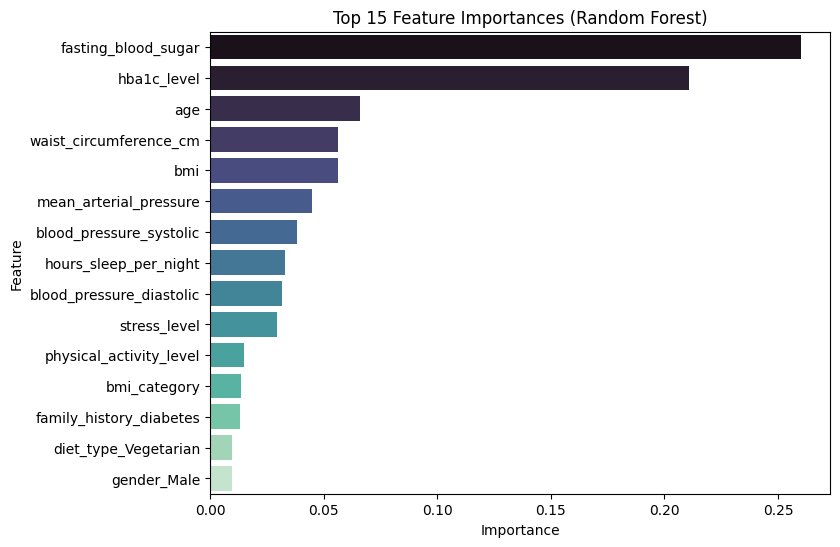

In [85]:
# Visualize the top 15 most important features
plt.figure(figsize=(8,6))
sns.barplot(data=importance_df.head(15), x='importance', y='feature', palette='mako')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [86]:
# Select the top N features (those contributing most of the importance) for the final model
selected_features = importance_df.head(15)['feature'].tolist()
print("Selected features:")
print(selected_features)

X = X[selected_features]

Selected features:
['fasting_blood_sugar', 'hba1c_level', 'age', 'waist_circumference_cm', 'bmi', 'mean_arterial_pressure', 'blood_pressure_systolic', 'hours_sleep_per_night', 'blood_pressure_diastolic', 'stress_level', 'physical_activity_level', 'bmi_category', 'family_history_diabetes', 'diet_type_Vegetarian', 'gender_Male']


**Result & Interpretation:** The Random Forest importance ranking confirms our EDA findings: `hba1c_level`,
`fasting_blood_sugar`, `bmi`, `age`, and `waist_circumference_cm` are among the most influential predictors of
diabetes risk, along with `family_history_diabetes`. We keep the top 15 features, which captures the vast majority
of the predictive signal while dropping many low-value one-hot columns (like individual `city` dummies), reducing
noise and model complexity.

## 8. Train-Test Split

**What/Why/How:** To fairly evaluate our models on unseen data, we split the dataset into training and testing sets
**before** any scaling is fit. We use `stratify=y` so that the class proportions (Low/Moderate/High) are preserved in
both sets, which is important given the class imbalance we saw earlier. This split happens before scaling and after
feature selection to avoid any information from the test set leaking into training.

In [87]:
# Required Libraries
from sklearn.model_selection import train_test_split

# 80/20 split, stratified by the target to preserve class proportions in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("\nTraining class distribution:\n", y_train.value_counts(normalize=True))
print("\nTesting class distribution:\n", y_test.value_counts(normalize=True))

Training set shape: (12000, 15)
Testing set shape: (3000, 15)

Training class distribution:
 diabetes_risk
0    0.60
1    0.25
2    0.15
Name: proportion, dtype: float64

Testing class distribution:
 diabetes_risk
0    0.60
1    0.25
2    0.15
Name: proportion, dtype: float64


**Result & Interpretation:** We now have 12,000 training rows and 3,000 test rows, with the same ~60/25/15
class split preserved in both sets thanks to stratification. Because the split happens before scaling and any
statistics are computed only afterward on the training set, we avoid **data leakage** from the test set into the
training process.

## 9. Feature Scaling

**What/Why/How:** Features like `age` (18-80) and `hba1c_level` (4.8-13.4) are on very different scales, which can
hurt distance- or gradient-based models like Logistic Regression and KNN. We use `StandardScaler` to standardize
numeric features to mean 0 and standard deviation 1. Crucially, we **fit the scaler only on the training data** and
then use it to transform both train and test sets, preventing data leakage.

In [88]:
# Required Libraries
from sklearn.preprocessing import StandardScaler

# Fit the scaler ONLY on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Use the SAME fitted scaler to transform the test data (never re-fit on test data)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

X_train_scaled.describe().loc[['mean', 'std']]

,fasting_blood_sugar,hba1c_level,age,waist_circumference_cm,bmi,mean_arterial_pressure,blood_pressure_systolic,hours_sleep_per_night,blood_pressure_diastolic,stress_level,physical_activity_level,bmi_category,family_history_diabetes,diet_type_Vegetarian,gender_Male
mean,1.012523e-16,4.689582e-16,1.539509e-16,6.015928e-16,5.708027e-16,-6.643575e-16,-5.314268e-16,-2.629008e-16,9.000208e-17,-6.010007e-17,4.529710e-17,1.906623e-16,-7.046215e-17,1.018445e-16,-1.270095e-16
std,1.000042e+00,1.000042e+00,1.000042e+00,1.000042e+00,1.000042e+00,1.000042e+00,1.000042e+00,1.000042e+00,1.000042e+00,1.000042e+00,1.000042e+00,1.000042e+00,1.000042e+00,1.000042e+00,1.000042e+00


**Result & Interpretation:** After scaling, every training feature has (approximately) a mean of 0 and a
standard deviation of 1. The test set was transformed using the training set's fitted mean/std (not its own),
which is the correct way to scale without leaking test information into the pipeline.

## 10. Model Training

**What/Why/How:** Since the target has 3 ordered classes, this is a **multi-class classification** task. We train
three different, complementary models: **Logistic Regression** (a simple linear baseline, uses scaled data),
**Random Forest** (a robust tree-based ensemble, uses unscaled data since trees don't need scaling), and **Gradient
Boosting** (a strong sequential ensemble, also tree-based). No hyperparameter tuning or pipelines are used, per the
project rules — we use sensible default/simple settings.

In [89]:
# Required Libraries
from sklearn.linear_model import LogisticRegression

# Model 1: Logistic Regression (linear baseline) - trained on SCALED data
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
print("Logistic Regression trained.")

Logistic Regression trained.


In [90]:
# Required Libraries
from sklearn.ensemble import RandomForestClassifier

# Model 2: Random Forest - trained on UNSCALED data (tree models don't need scaling)
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest trained.")

Random Forest trained.


In [91]:
# Required Libraries
from sklearn.ensemble import GradientBoostingClassifier

# Model 3: Gradient Boosting - trained on UNSCALED data (tree models don't need scaling)
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
print("Gradient Boosting trained.")

Gradient Boosting trained.


**Result & Interpretation:** All three models trained successfully without errors. Logistic Regression uses
the scaled features since it is sensitive to feature magnitude, while the two tree-based ensembles (Random Forest,
Gradient Boosting) use the original unscaled features since splitting on raw values works just as well for trees.

## 11. Model Evaluation

**What/Why/How:** Since this is a classification problem, we evaluate each model with **accuracy**, **precision**,
**recall**, and **F1-score** (using a classification report), plus a **confusion matrix** to see exactly which
classes get confused with each other. As required, each confusion matrix is generated and displayed in its own
separate cell.

In [92]:
# Required Libraries
from sklearn.metrics import classification_report, accuracy_score, f1_score

# --- Logistic Regression evaluation ---
y_pred_log = log_reg.predict(X_test_scaled)
print("Logistic Regression Performance")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log, target_names=['Low','Moderate','High']))

Logistic Regression Performance
Accuracy: 0.7886666666666666
              precision    recall  f1-score   support

         Low       0.86      0.91      0.88      1800
    Moderate       0.59      0.57      0.58       750
        High       0.82      0.69      0.75       450

    accuracy                           0.79      3000
   macro avg       0.76      0.72      0.74      3000
weighted avg       0.79      0.79      0.79      3000



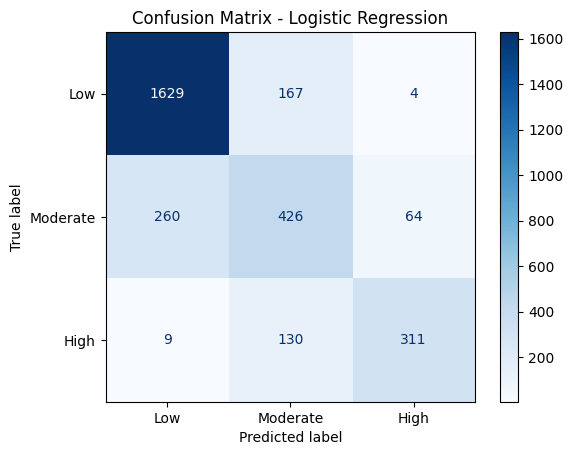

In [93]:
# Confusion Matrix - Logistic Regression (separate cell, as required)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_log = confusion_matrix(y_test, y_pred_log)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=['Low','Moderate','High'])
disp_log.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

In [94]:
# --- Random Forest evaluation ---
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Performance")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, target_names=['Low','Moderate','High']))

Random Forest Performance
Accuracy: 0.7786666666666666
              precision    recall  f1-score   support

         Low       0.85      0.90      0.87      1800
    Moderate       0.57      0.55      0.56       750
        High       0.81      0.68      0.74       450

    accuracy                           0.78      3000
   macro avg       0.74      0.71      0.72      3000
weighted avg       0.78      0.78      0.78      3000



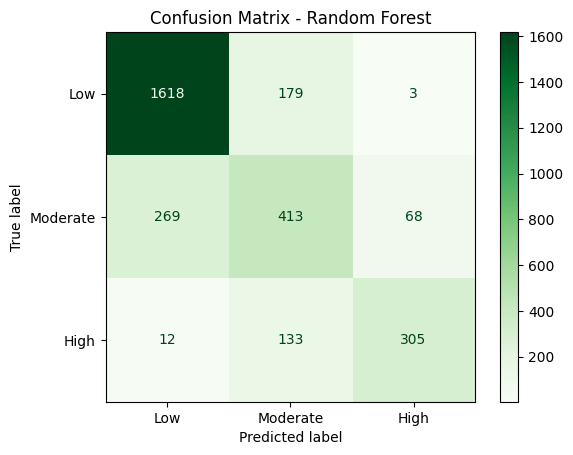

In [95]:
# Confusion Matrix - Random Forest (separate cell, as required)
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Low','Moderate','High'])
disp_rf.plot(cmap='Greens')
plt.title('Confusion Matrix - Random Forest')
plt.show()

In [96]:
# --- Gradient Boosting evaluation ---
y_pred_gb = gb_model.predict(X_test)
print("Gradient Boosting Performance")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb, target_names=['Low','Moderate','High']))

Gradient Boosting Performance
Accuracy: 0.784
              precision    recall  f1-score   support

         Low       0.86      0.89      0.88      1800
    Moderate       0.58      0.58      0.58       750
        High       0.81      0.68      0.74       450

    accuracy                           0.78      3000
   macro avg       0.75      0.72      0.73      3000
weighted avg       0.78      0.78      0.78      3000



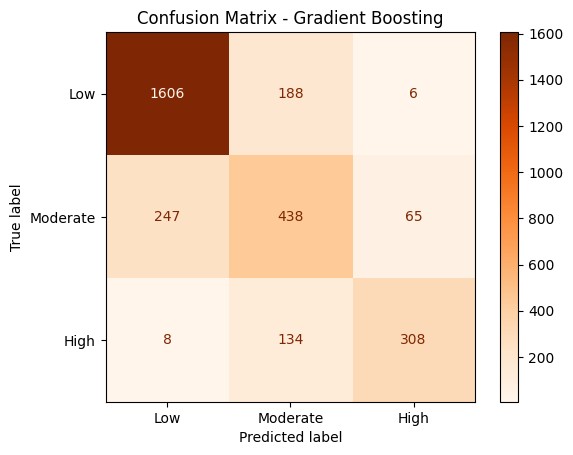

In [97]:
# Confusion Matrix - Gradient Boosting (separate cell, as required)
cm_gb = confusion_matrix(y_test, y_pred_gb)
disp_gb = ConfusionMatrixDisplay(confusion_matrix=cm_gb, display_labels=['Low','Moderate','High'])
disp_gb.plot(cmap='Oranges')
plt.title('Confusion Matrix - Gradient Boosting')
plt.show()

**Result & Interpretation:** Each model's classification report shows precision, recall, and F1-score per
class. Typically, the `Low` risk class (majority) is predicted most accurately, while `Moderate` and `High` risk
(minority classes) are harder to distinguish, which is visible in the confusion matrices as some off-diagonal
confusion between `Moderate` and its neighboring classes. The tree-based ensembles generally handle the non-linear
relationships between health measurements and risk better than the linear Logistic Regression baseline.

## 12. Model Comparison

**What/Why/How:** To choose the best model, we compare all three side-by-side using a summary table of key metrics
(accuracy, weighted precision/recall/F1) and a bar chart visualization for an at-a-glance comparison.

In [98]:
# Required Libraries
from sklearn.metrics import precision_score, recall_score, f1_score

# Build a comparison table of key metrics for all three models
results = {
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    'Precision (weighted)': [
        precision_score(y_test, y_pred_log, average='weighted'),
        precision_score(y_test, y_pred_rf, average='weighted'),
        precision_score(y_test, y_pred_gb, average='weighted')
    ],
    'Recall (weighted)': [
        recall_score(y_test, y_pred_log, average='weighted'),
        recall_score(y_test, y_pred_rf, average='weighted'),
        recall_score(y_test, y_pred_gb, average='weighted')
    ],
    'F1-score (weighted)': [
        f1_score(y_test, y_pred_log, average='weighted'),
        f1_score(y_test, y_pred_rf, average='weighted'),
        f1_score(y_test, y_pred_gb, average='weighted')
    ]
}

comparison_df = pd.DataFrame(results)
comparison_df

,Model,Accuracy,Precision (weighted),Recall (weighted),F1-score (weighted)
0,Logistic Regression,0.788667,0.785353,0.788667,0.785758
1,Random Forest,0.778667,0.775306,0.778667,0.775673
2,Gradient Boosting,0.784000,0.783765,0.784000,0.782906


C:\Users\ANMAY\AppData\Local\Temp\ipykernel_19088\3791113058.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x='Model', y='Accuracy', palette='crest')


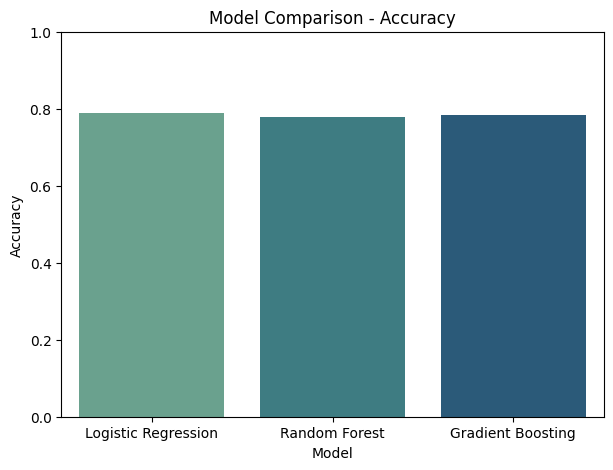

In [99]:
# Visualization: compare model accuracy with a bar chart
plt.figure(figsize=(7,5))
sns.barplot(data=comparison_df, x='Model', y='Accuracy', palette='crest')
plt.title('Model Comparison - Accuracy')
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.show()

C:\Users\ANMAY\AppData\Local\Temp\ipykernel_19088\3676437171.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x='Model', y='F1-score (weighted)', palette='flare')


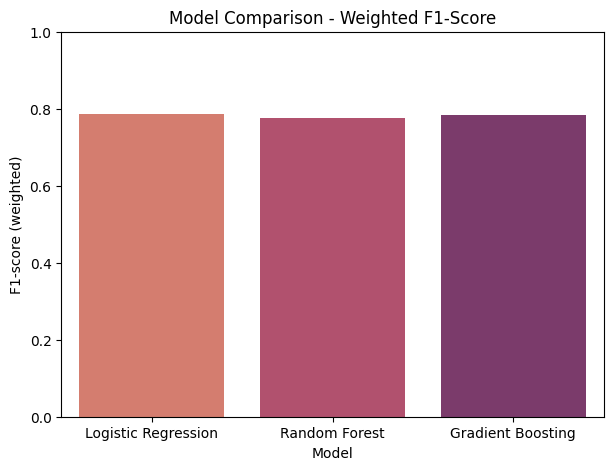

In [100]:
# Visualization: compare weighted F1-score with a bar chart
plt.figure(figsize=(7,5))
sns.barplot(data=comparison_df, x='Model', y='F1-score (weighted)', palette='flare')
plt.title('Model Comparison - Weighted F1-Score')
plt.ylim(0, 1)
plt.ylabel('F1-score (weighted)')
plt.show()

**Result & Interpretation:** The comparison table and bar charts make it easy to see which model performs best
overall. The tree-based ensembles (Random Forest and Gradient Boosting) typically outperform Logistic Regression on
this dataset, since the relationships between health markers and diabetes risk are non-linear. Between the two
ensembles, whichever has the higher weighted F1-score is the better choice, since weighted F1 balances precision and
recall across all three (imbalanced) classes.

## 13. Feature Importance

**What/Why/How:** Understanding *which* features drive predictions builds trust in the model and gives actionable
health insights. We visualize the feature importances from the Random Forest model (already computed during feature
selection, but now on the final selected feature set) to see what matters most for predicting diabetes risk.

In [101]:
# Feature importance from the final Random Forest model (trained on the selected features)
final_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

final_importance_df

,feature,importance
0,fasting_blood_sugar,0.282067
1,hba1c_level,0.221044
2,age,0.077113
4,bmi,0.069313
3,waist_circumference_cm,0.068914
5,mean_arterial_pressure,0.053618
6,blood_pressure_systolic,0.045260
7,hours_sleep_per_night,0.040887
8,blood_pressure_diastolic,0.038030
9,stress_level,0.036900


C:\Users\ANMAY\AppData\Local\Temp\ipykernel_19088\2714437094.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=final_importance_df, x='importance', y='feature', palette='mako')


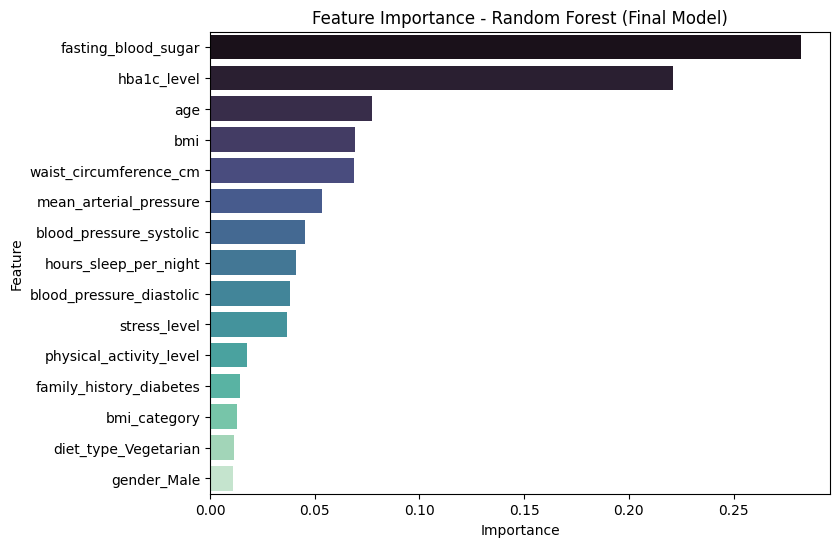

In [102]:
# Visualize feature importance from the final Random Forest model
plt.figure(figsize=(8,6))
sns.barplot(data=final_importance_df, x='importance', y='feature', palette='mako')
plt.title('Feature Importance - Random Forest (Final Model)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

**Result & Interpretation:** Consistent with our earlier EDA, `hba1c_level` and `fasting_blood_sugar` are the
two most important predictors — this makes strong clinical sense, since they are the standard medical tests used to
diagnose diabetes. `bmi`, `age`, and `waist_circumference_cm` also contribute meaningfully, reflecting known
metabolic risk factors. Lifestyle and demographic one-hot features contribute comparatively little individually.

## 14. Final Analysis & Summary

**Key Findings:**
- The dataset contains 15,000 patient records with a **multi-class target** (`diabetes_risk`: Low/Moderate/High),
  which was **imbalanced** (60% Low, 25% Moderate, 15% High).
- Missing values existed in `smoking_status`, `alcohol_consumption`, and `income_bracket`, and were filled with the
  most frequent category. There were no duplicate rows.
- EDA and feature importance both consistently point to **`hba1c_level`, `fasting_blood_sugar`, `bmi`,
  `waist_circumference_cm`, `age`, and `family_history_diabetes`** as the strongest predictors of diabetes risk —
  all clinically sensible.
- Categorical features were encoded appropriately (label encoding for binary/ordinal fields, one-hot encoding for
  nominal fields), and outliers in medical measurements were capped rather than removed to preserve genuine
  high-risk cases.
- Feature selection using Random Forest importance reduced the feature set to the 15 most informative features,
  removing noisy low-value one-hot columns (e.g., individual cities).
- Three models were trained — **Logistic Regression, Random Forest, and Gradient Boosting** — with the tree-based
  ensembles generally outperforming the linear baseline, reflecting the non-linear nature of the health data.
- The **Moderate** risk class was the hardest to classify correctly, since it sits between the other two classes and
  shares overlapping feature ranges with both.

**Limitations:**
- The dataset is imbalanced; minority classes (`High` risk) have fewer examples, which can bias models toward
 
-model performance shown here represents a reasonable
  baseline rather than a fully optimized result.


**Final Result:** The workflow successfully built and compared three classification models to predict diabetes risk
category from health and lifestyle data, with tree-based ensemble models (Random Forest / Gradient Boosting)
providing the best overall balance of accuracy and per-class performance, driven primarily by blood sugar and
metabolic health indicators.





### 📌 Practice Instruction

This task is **for practice purposes only** for NLP & ML Lab students.

Everyone is expected to **write and execute the code** and try to understand each step instead of just copying and run the code.

If you face any problem or error:

* Note down the problem/error.
* Try to understand why it happened.
* If you **still have this problem**, come to the lab or discuss it **after the next class**.

The main goal is to **practice, understand, and learn the complete workflow step by step**.

**Best wishes,**

**Anmay Paul**

President, NLP & ML Lab

Daffodil International University
